# Statistical Arbitrage and Mathematical Application to Counter Strike's Skin Market.
* This script is designed to apply mathematical, and statistical concepts into the Counter Stike market, and to provide insights into the market trends, and to help players make informed decisions when buying or selling items. 
* This is strictly for educational use only and should not be applied for real money.
* Due To pricing and documentation issue, this price data is simu;ated and does not accurately represent the price for the in-game items.

## Thesis
* With the upbringing of utilizing mathematical models within prediction market, application of these concepts will provide an edge than buy and hold.

## Hypothesis
* If I apply mathematical and statistical models to Counter-Strike skin markets, then it will outperform buy-and-hold because skin prices exhibit predictable paterns that statistical strategies can systematically cpature before the broad market corrects.

In [36]:
# Import Libraries and Import the basic APIs

import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [37]:
## User Inputs
name = input("Enter the Dataset Name: ") #ask the user to input the name of the dataset
fast_window = int(input("Enter the Fast Moving Average Window: ")) #ask the user to input the fast moving average window
slow_window = int(input("Enter the Slow Moving Average Window: ")) #ask the user to
initial_equity = float(input("Enter the Initial Equity: ")) #ask the user to input the initial equity


In [38]:

# Load the dataset

df = pd.read_csv('Weapons_Case_Price_Data_CSGO.csv') #load the dataset
day = np.arange(1, len(df) + 1) #add a new column to the dataset with the day number
df['Day'] = day #add the new column to the dataset
df = df[['Date','Day', "Price (USD)", "Volume"]] #Reorder the columns in the dataset
df.head() #display the first 5 rows of the dataset


,Date,Day,Price (USD),Volume
0,Aug 14 2013 01: +0,1,8.528,38
1,Aug 15 2013 01: +0,2,5.436,5412
2,Aug 16 2013 01: +0,3,3.351,9877
3,Aug 17 2013 01: +0,4,2.621,11050
4,Aug 18 2013 01: +0,5,2.665,11485


In [39]:
df.info() #display the information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5059 entries, 0 to 5058
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         5059 non-null   object 
 1   Day          5059 non-null   int64  
 2   Price (USD)  5059 non-null   float64
 3   Volume       5059 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 158.2+ KB


## Add and Transform the data
* Lets add a simple linear regression model.
* lets add a simple moving average model.
* lets apply a mean reversion/statistical arbitrage model using oscillators, z scores and standard deviation.
* Correlation Model to speculative markert? (S&P and BTC)?
* Calculate Drawdown and Volatility


In [40]:
## First Get the slope and the regression line of the price over time

slope = (df['Price (USD)'].iloc[-1] - df['Price (USD)'].iloc[0]) / (df['Day'].iloc[-1] - df['Day'].iloc[0]) #calculate the slope
x = df['Day'] #x-axis values
y = df['Price (USD)'] #y-axis values
slope_intercept = df['Price (USD)'].iloc[0] - slope * df['Day'].iloc[0]
regression_line = slope * x + slope_intercept #calculate the regression line
df['Regression Line'] = regression_line #add the regression line to the dataset
df.head()

# Conclusion, This is not a reliable way to predict the price of the item because it underfits the data.
# The price of the item is not increasing at a constant rate, and there are many fluctuations in the price.
# R != > 0.5, which means that the regression line does not fit the data well.

,Date,Day,Price (USD),Volume,Regression Line
0,Aug 14 2013 01: +0,1,8.528,38,8.528000
1,Aug 15 2013 01: +0,2,5.436,5412,8.570626
2,Aug 16 2013 01: +0,3,3.351,9877,8.613252
3,Aug 17 2013 01: +0,4,2.621,11050,8.655878
4,Aug 18 2013 01: +0,5,2.665,11485,8.698504


In [ ]:
## Get Simple Moving Average
df["Fast Moving Average"] = df["Price (USD)"].rolling(window=fast_window).mean()
df["Slow Moving Average"] = df["Price (USD)"].rolling(window=slow_window).mean()

#get crossover signal
df["MA_Signal"] = 0.0
df["MA_Signal"] = np.where(df['Fast Moving Average'] > df['Slow Moving Average'], 1.0, 0.0)
df["Position"] = df["MA_Signal"].diff() #calculate the position of the signal



#Old Pinescript Logic for Equity Calculation, I will convert it to Python using np.where() function

#f df["Signal"] == 1.0:
#    df["Equity"] = initial_equity * (df["Price (USD)"] / df["Price (USD)"].iloc[-1]) 
#elif df["Signal"] == 0.0 and df["Signal"].shift(1) == 1.0:
#    df["Equity"] = initial_equity * (1 - (df["Price (USD)"] / df["Price (USD)"].iloc[-1]))
#else:
#    df["Equity"] = initial_equity

df["Moving_Average_Equity"] = np.where(
    df["MA_Signal"] == 1.0,
    initial_equity * (df["Price (USD)"] / df["Price (USD)"].iloc[-1]),
    np.where(
        (df["MA_Signal"] == 0.0) & (df["MA_Signal"].shift(1) == 1.0),
        initial_equity * (1 - (df["Price (USD)"] / df["Price (USD)"].iloc[-1])),
        initial_equity
    )
)
df.head()



KeyError: 'Signal'

In [ ]:
## Calculate Returns

## Plot the Data and Analyze

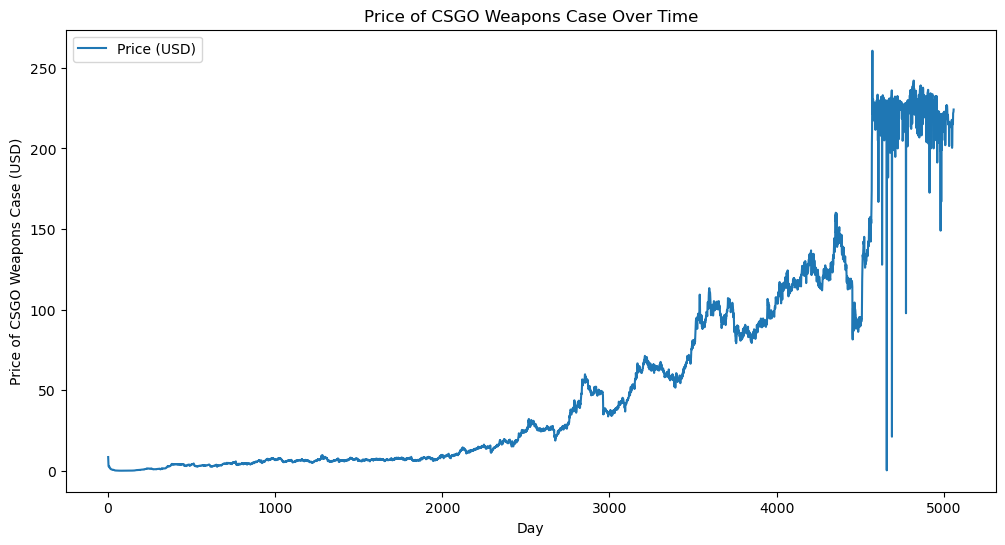

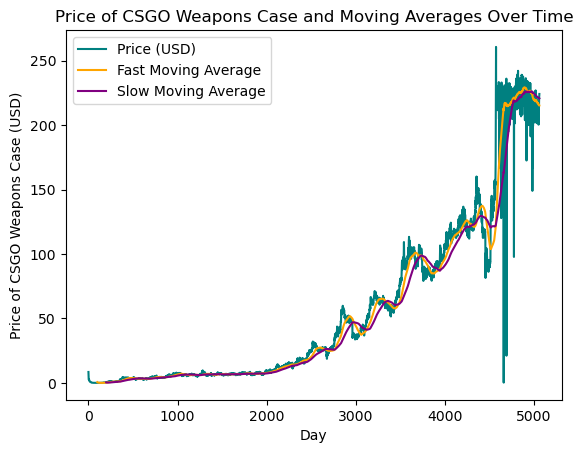

In [49]:
plot_MA = bool(input("Do you want to plot the Moving Averages? (True/False): ")) #ask the user if they want to plot the moving averages
plot_Returns = bool(input("Do you want to plot the Returns? (True/False): ")) #ask the user if they want to plot the returns


plt.figure(figsize=(12,6))
plt.plot(df["Day"], df["Price (USD)"], label="Price (USD)")
plt.xlabel("Day")
plt.ylabel(f"Price of {name} (USD)")
plt.title(f"Price of {name} Over Time")
plt.legend()
plt.show()
if plot_MA:
    plt.plot(df["Day"], df["Price (USD)"], label="Price (USD)", color = "teal")
    plt.plot(df["Day"], df["Fast Moving Average"], label="Fast Moving Average", color = "orange")
    plt.plot(df["Day"], df["Slow Moving Average"], label="Slow Moving Average", color = "purple")
    plt.xlabel("Day")
    plt.ylabel(f"Price of {name} (USD)")
    plt.title(f"Price of {name} and Moving Averages Over Time")
    plt.legend()
    plt.show()



In [ ]:
## Returns Plot
buy_and_hold_returns =

## Final Conclusion